# Introductie

In deze notebook voeren we een verkennende analyse uit op een dataset met gezondheidsvariabelen.
Het doel is om inzicht te krijgen in de structuur van de data, relaties tussen variabelen te ontdekken en de dataset voor te bereiden op machine learning.

De gebruiKte dataset is de Heart attack dataset (https://www.kaggle.com/datasets/prasad22/healthcare-dataset/data) 

De analyse bestaat uit:
- Verkennen van de dataset
- Analyse van individuele variabelen
- Analyse van relaties tussen variabelen
- Normalisatie en voorbereiding voor machine learning

# DEEL 1 – EDA en preprocessing voorbereiding

## 1. Introductie dataset

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [58]:
df = pd.read_csv("cardiovascular_risk_dataset.csv")
df.head()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


De dataset bevat zowel numerieke als categorische variabelen en bestaat uit meerdere observaties. Het doel is om patronen te ontdekken en de data geschikt te maken voor machine learning.

## 2. Algemene inspectie

In [59]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        5500 non-null   int64  
 1   age                               5500 non-null   int64  
 2   bmi                               5500 non-null   float64
 3   systolic_bp                       5500 non-null   int64  
 4   diastolic_bp                      5500 non-null   int64  
 5   cholesterol_mg_dl                 5500 non-null   int64  
 6   resting_heart_rate                5500 non-null   int64  
 7   smoking_status                    5500 non-null   object 
 8   daily_steps                       5500 non-null   int64  
 9   stress_level                      5500 non-null   int64  
 10  physical_activity_hours_per_week  5500 non-null   float64
 11  sleep_hours                       5500 non-null   float64
 12  family

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,2750.500000,53.872000,28.170818,147.248182,95.756727,239.684182,74.075091,5902.929455,4.907091,3.299364,6.869364,5.162909,3.782200,37.540455
std,1587.857571,21.196017,4.189877,13.222701,9.451559,28.570177,6.392166,3041.084590,2.298173,2.672457,1.091263,2.286134,3.515594,24.287026
min,1.000000,18.000000,15.000000,108.000000,64.000000,147.000000,48.000000,500.000000,1.000000,0.000000,4.000000,1.000000,0.000000,0.000000
25%,1375.750000,36.000000,25.200000,138.000000,89.000000,220.000000,70.000000,3428.000000,3.000000,1.200000,6.200000,3.000000,1.200000,18.400000
50%,2750.500000,54.000000,28.400000,147.000000,96.000000,240.000000,74.000000,5460.000000,5.000000,2.600000,6.900000,5.000000,2.800000,36.700000
75%,4125.250000,72.000000,31.100000,156.000000,102.000000,260.000000,79.000000,7772.000000,7.000000,4.900000,7.600000,7.000000,5.300000,55.500000
max,5500.000000,90.000000,40.900000,192.000000,120.000000,331.000000,92.000000,16793.000000,10.000000,12.900000,10.000000,10.000000,29.200000,100.000000


De dataset bevat voornamelijk numerieke variabelen, waaronder medische metingen (zoals bloeddruk en cholesterol) en leefstijlfactoren.

De dataset bevat een combinatie van medische metingen en leefstijlfactoren, wat relevant is voor het analyseren van gezondheidsrisico’s. De meeste variabelen zijn numeriek, waardoor ze direct bruikbaar zijn voor analyse en modellering. De aanwezigheid van n categorische variabele (smoking_status) betekent dat er later nog encoding nodig kan zijn.

## 3. Missende waarden

Er wordt gecontroleerd op missende waarden per kolom.

In [60]:
df.isnull().sum()
(df.isnull().sum() / len(df)) * 100

Patient_ID                          0.0
age                                 0.0
bmi                                 0.0
systolic_bp                         0.0
diastolic_bp                        0.0
cholesterol_mg_dl                   0.0
resting_heart_rate                  0.0
smoking_status                      0.0
daily_steps                         0.0
stress_level                        0.0
physical_activity_hours_per_week    0.0
sleep_hours                         0.0
family_history_heart_disease        0.0
diet_quality_score                  0.0
alcohol_units_per_week              0.0
heart_disease_risk_score            0.0
risk_category                       0.0
dtype: float64

De dataset bevat weinig tot geen missende waarden, wat betekent dat de datakwaliteit relatief hoog is. Hierdoor zijn er geen ingrijpende stappen zoals imputatie of het verwijderen van kolommen nodig, wat het analyseproces vereenvoudigt.

## 4. verdeling van numerieke features
De verdelingen van variabelen zoals age, bmi, cholesterol_mg_dl en daily_steps worden geanalyseerd.

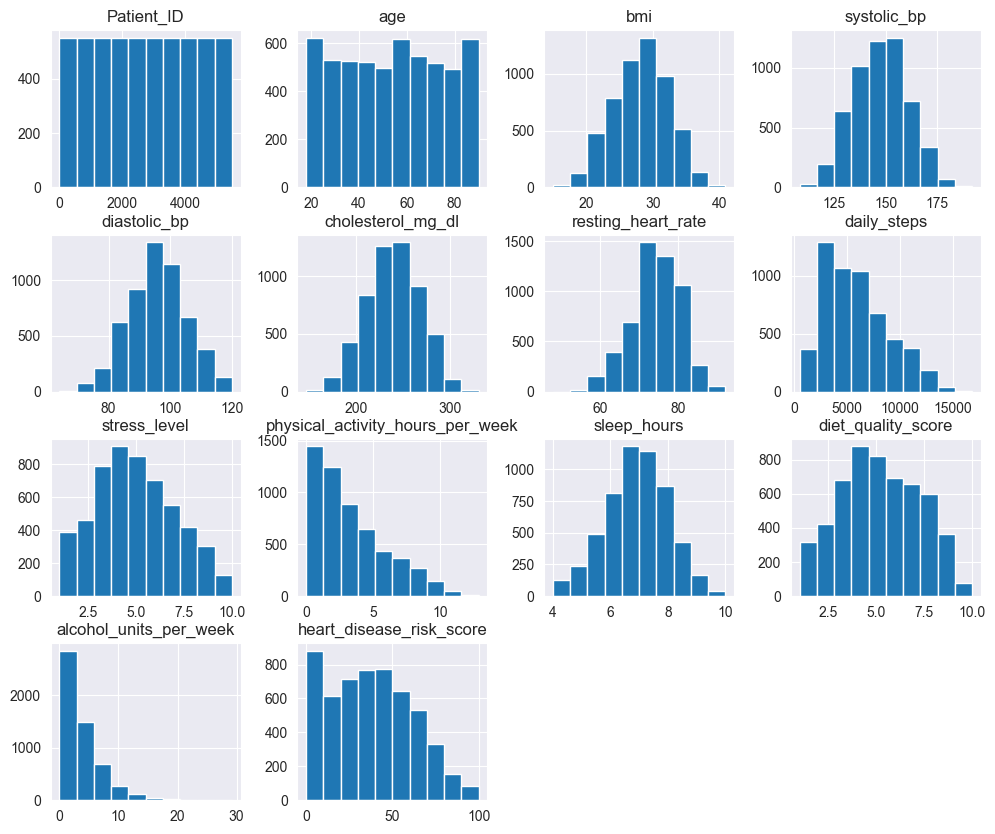

In [61]:
df.hist(figsize=(12,10))
plt.show()

De variabelen vertonen verschillende verdelingen en schalen. Met name daily_steps heeft een veel grotere range dan de andere variabelen, terwijl bijvoorbeeld stress_level en bmi binnen een kleinere bandbreedte vallen. Dit verschil in schaal kan invloed hebben op modellen en maakt normalisatie of standaardisatie wenselijk.

### Outliers
Boxplots worden gebruikt om uitschieters in belangrijke numerieke variabelen te detecteren.

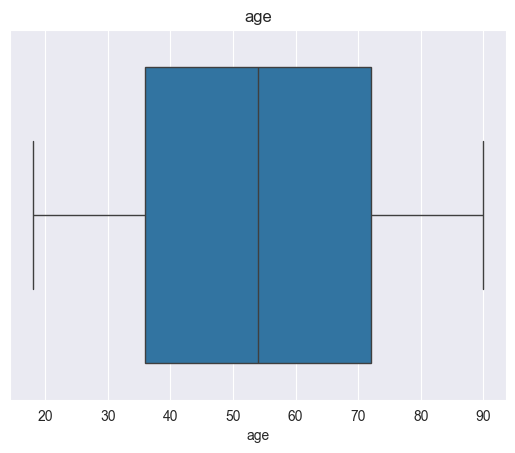

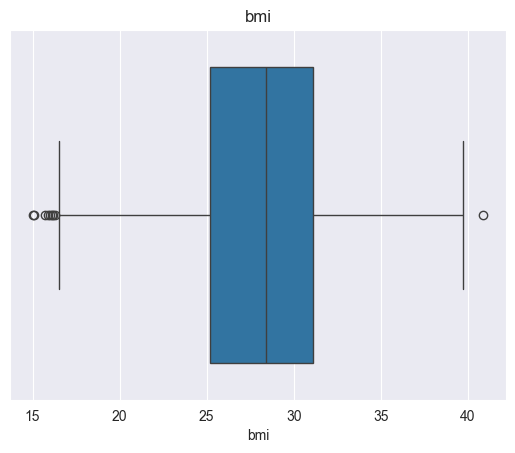

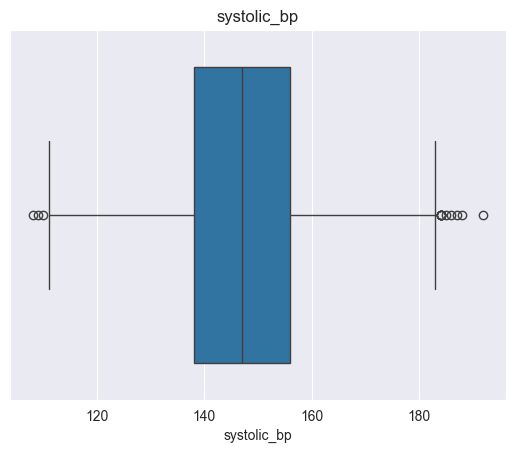

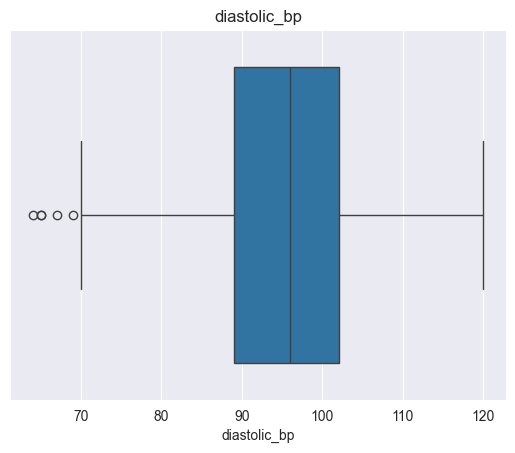

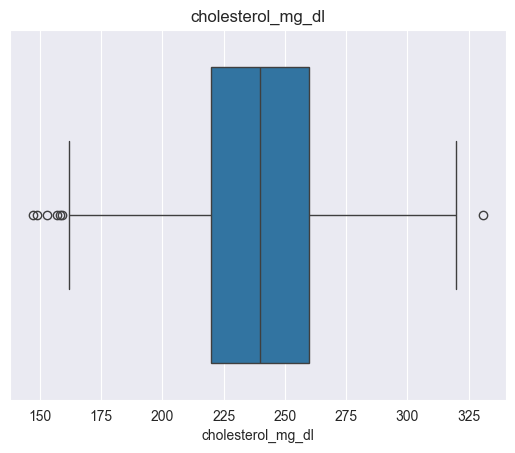

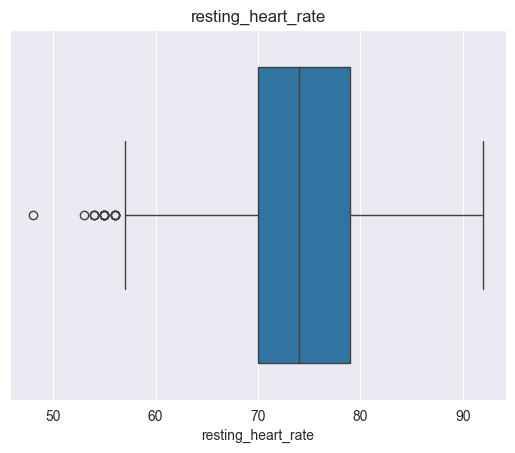

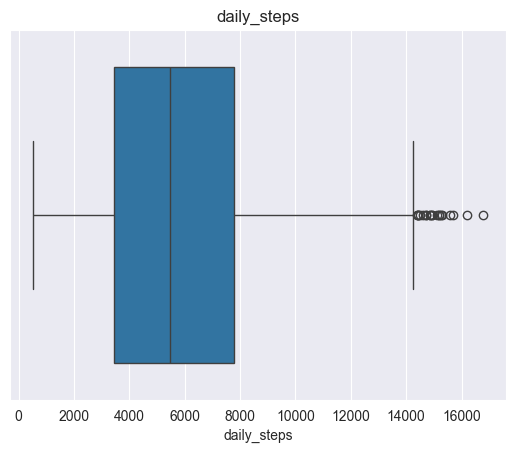

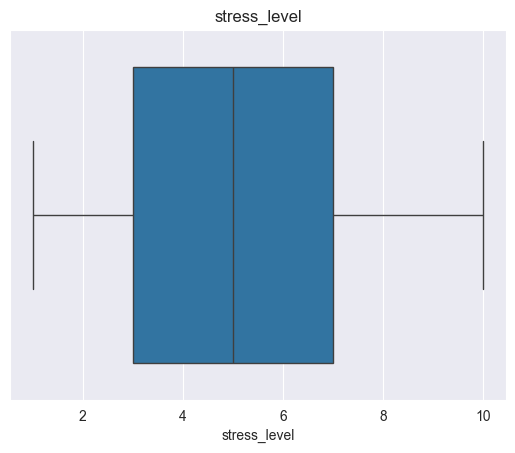

In [62]:
cols = ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 
        'cholesterol_mg_dl', 'resting_heart_rate', 
        'daily_steps', 'stress_level']

for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Er zijn duidelijke outliers aanwezig, vooral bij daily_steps, maar ook bij bloeddruk en cholesterol. Deze extreme waarden kunnen het model beïnvloeden, afhankelijk van het type algoritme. Het is daarom belangrijk om later te bepalen of deze outliers behouden blijven (bijv. als ze realistisch zijn) of worden aangepast/verwijderd.

### Correlaties
De correlatiematrix laat zien hoe variabelen onderling samenhangen.

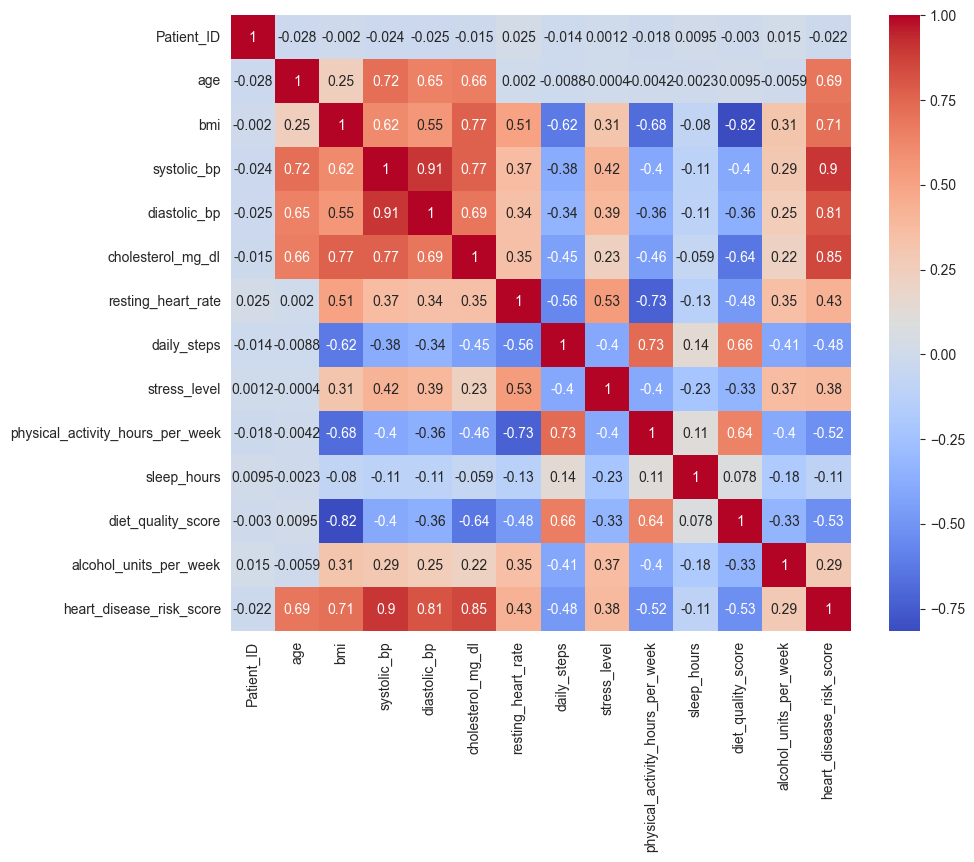

In [63]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

De correlaties laten zien dat sommige variabelen onderling samenhangen, zoals systolic_bp en diastolic_bp. Dit is logisch gezien de aard van de metingen. Andere variabelen lijken minder sterk gerelateerd, wat betekent dat ze mogelijk aanvullende, unieke informatie leveren aan een model.

## 5. Categorische variabelen
De verdeling van de categorische variabele (gegevens die geen getal zijn) worden bekeken.

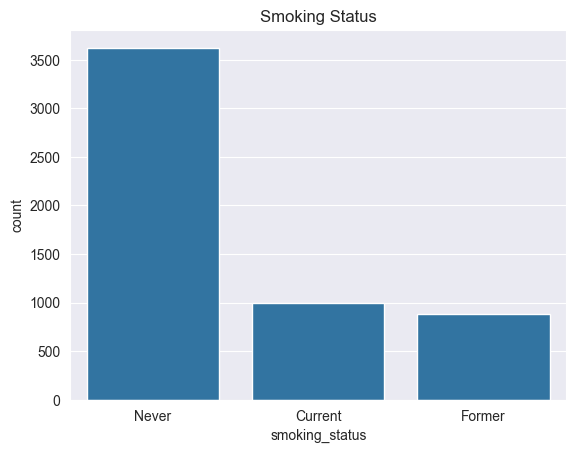

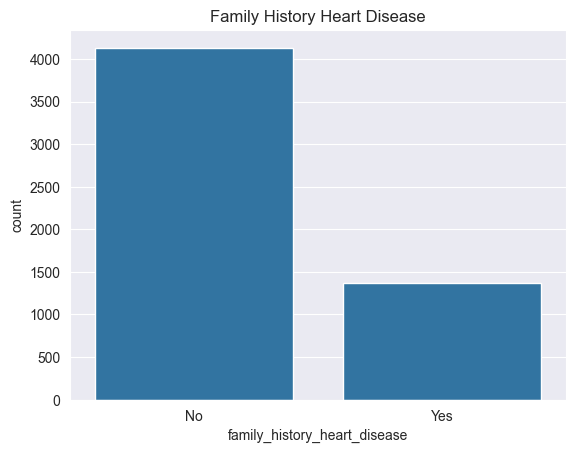

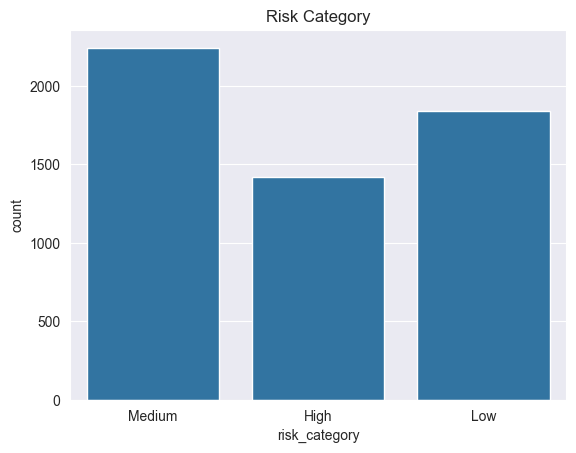

In [72]:
# smoking_status
sns.countplot(x=df['smoking_status'])
plt.title("Smoking Status")
plt.show()

# family history
sns.countplot(x=df['family_history_heart_disease'])
plt.title("Family History Heart Disease")
plt.show()

# target
sns.countplot(x=df['risk_category'])
plt.title("Risk Category")
plt.show()

De categorische variabelen geven inzicht in belangrijke risicofactoren. smoking_status en family_history_heart_disease beschrijven leefstijl en genetische aanleg, die beide invloed kunnen hebben op cardiovasculair risico. De targetvariabele risk_category laat de verdeling van risiconiveaus zien en maakt duidelijk of de dataset gebalanceerd is. Dit is belangrijk, omdat een scheve verdeling invloed kan hebben op modelprestaties.

## 6. Eerste preprocessing stappen
hier worden de eerste stappen van preprocessing uitgevoerd, zoals het encoden van categorische variabelen en het schalen van numerieke features. Deze stappen zijn essentieel om de data geschikt te maken voor machine learning.

In [65]:
# Kopie maken van dataset
df_processed = df.copy()

### Categorische variabele encoden

In [66]:
# One-hot encoding
df_processed = pd.get_dummies(
    df_processed,
    columns=['smoking_status', 'family_history_heart_disease'],
    drop_first=True
)

### Features en target splitsen

In [67]:
X = df_processed.drop(columns=['Patient_ID', 'risk_category'])
y = df_processed['risk_category']

### Target encoden

In [68]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

De preprocessing bestaat uit het encoden van categorische variabelen en het omzetten van de target naar numerieke vorm. Het schalen / normaliseren van de features wordt in deel 2 van deze file gedaan. Daarnaast is kritisch gekeken naar mogelijke data leakage door sterk gerelateerde variabelen zoals heart_disease_risk_score. Deze stappen zorgen ervoor dat de dataset geschikt is voor betrouwbare modeltraining.

## 7. Conclusie deel 1

De verkennende data-analyse laat zien dat de dataset van goede kwaliteit is en relevante informatie bevat over zowel medische kenmerken als leefstijl. De variabelen geven gezamenlijk een breed beeld van factoren die invloed kunnen hebben op cardiovasculair risico.

Wel zijn er duidelijke verschillen in schaal tussen variabelen en zijn er outliers aanwezig in meerdere features. Daarnaast bevat de dataset zowel numerieke als categorische data, wat extra preprocessing vereist. Deze bevindingen vormen de basis voor de volgende stap, waarin de data wordt voorbereid voor modeltraining.

# Deel 2 - Feature analyse en patronen

## 1. Verdeling van variabelen
De verdeling van belangrijke variabelen wordt geanalyseerd om inzicht te krijgen in hun kenmerken

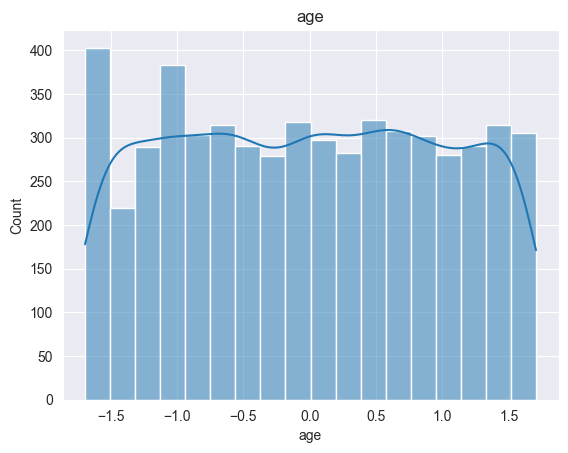

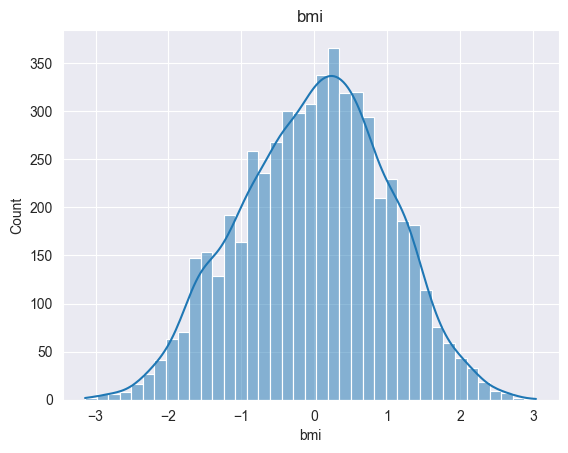

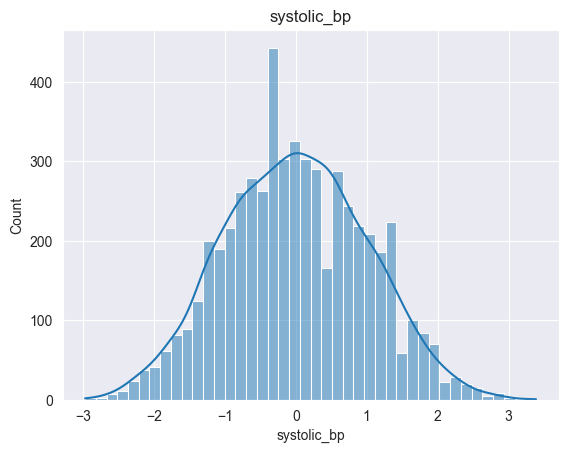

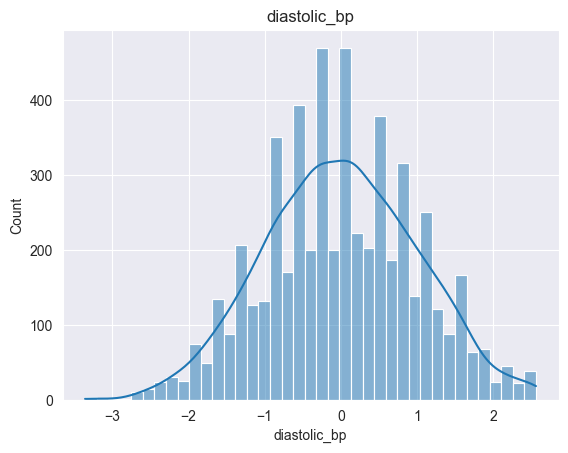

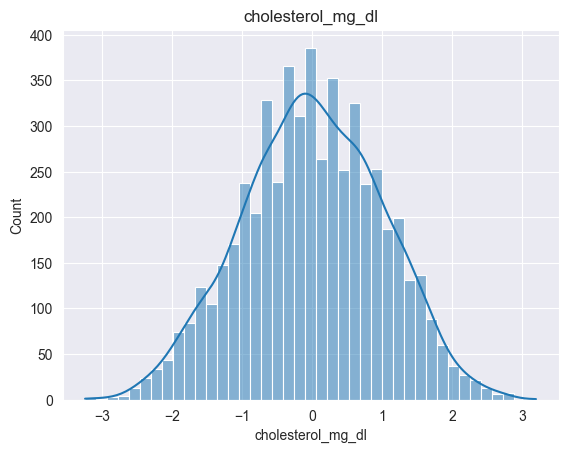

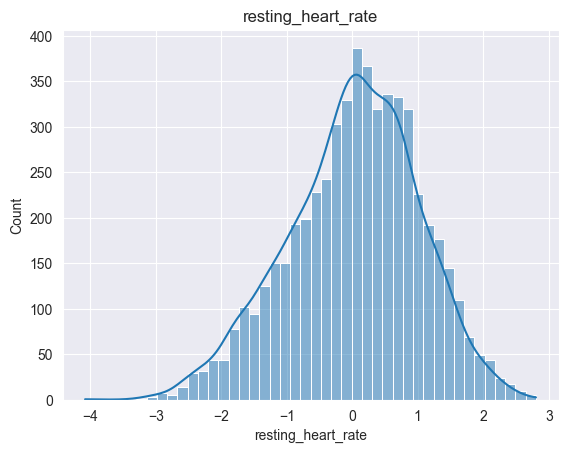

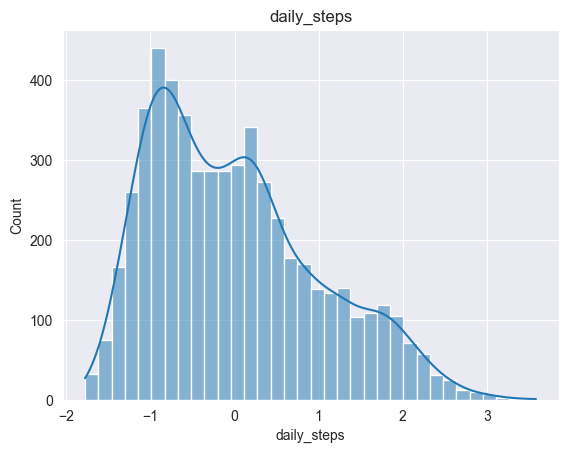

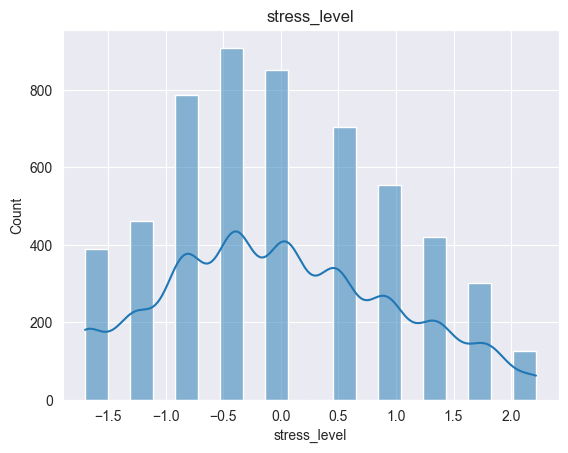

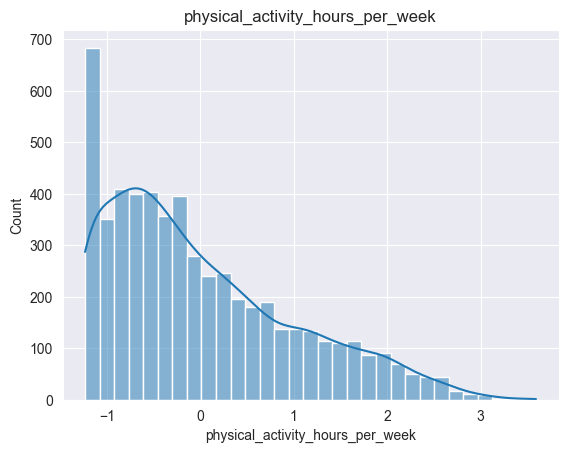

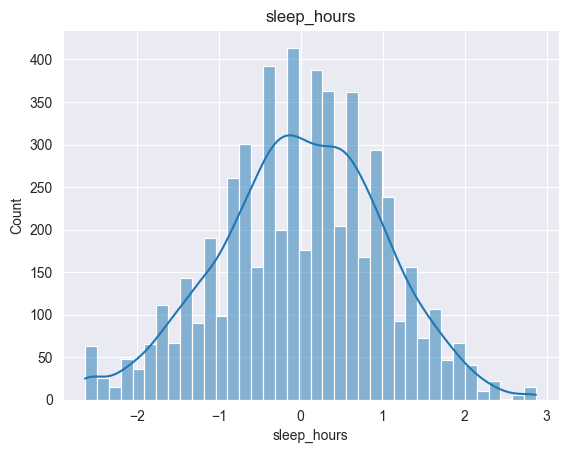

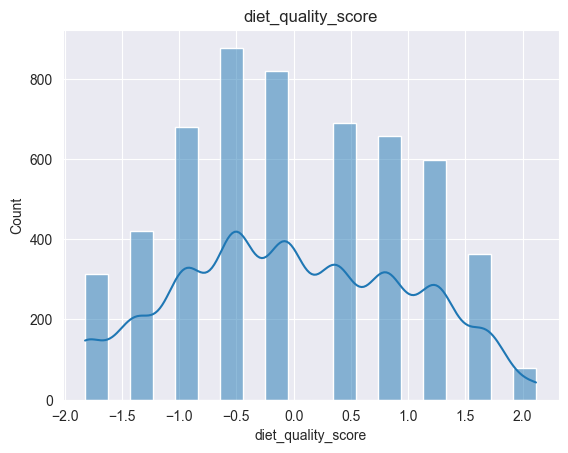

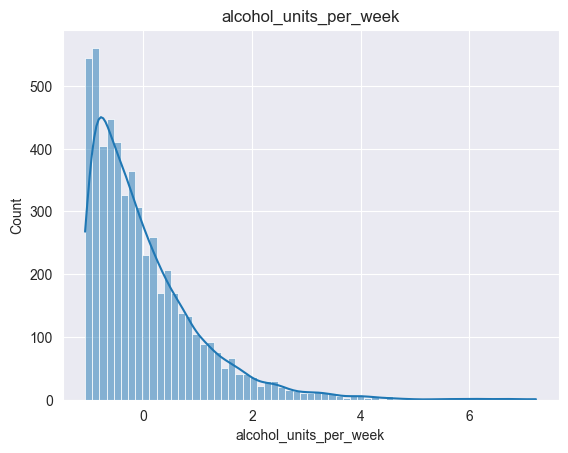

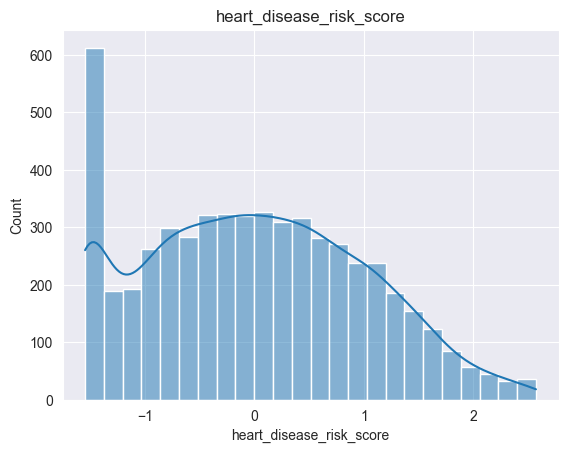

In [76]:
numeric_cols = [
    'age', 'bmi', 'systolic_bp', 'diastolic_bp',
    'cholesterol_mg_dl', 'resting_heart_rate',
    'daily_steps', 'stress_level',
    'physical_activity_hours_per_week',
    'sleep_hours', 'diet_quality_score',
    'alcohol_units_per_week',
    'heart_disease_risk_score'
]

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

De meeste variabelen zijn niet perfect normaal verdeeld. Sommige features vertonen een scheve verdeling (bijv. daily_steps, cholesterol_mg_dl), terwijl andere dichter bij een Gaussische verdeling liggen. Dit bevestigt dat schaal- en normalisatietechnieken relevant zijn.

## 2. Correlaties en relaties
De correlaties tussen variabelen worden geanalyseerd om onderlinge relaties te begrijpen.

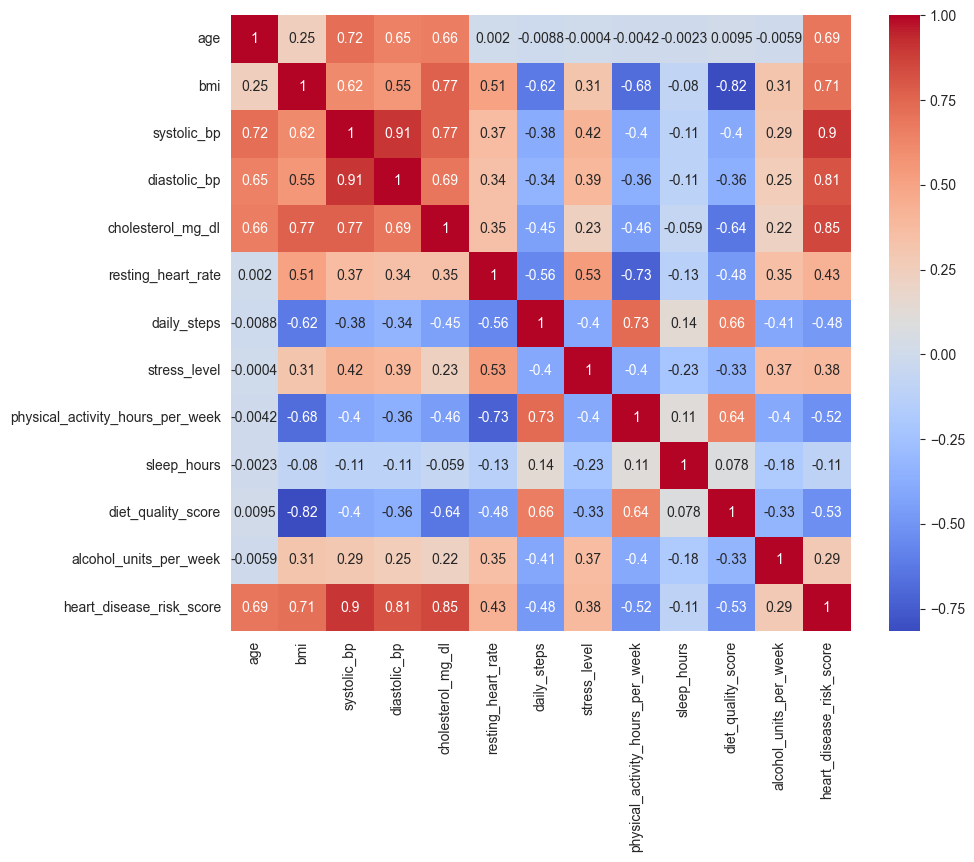

In [77]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

Er zijn duidelijke correlaties tussen bepaalde variabelen, zoals systolic_bp en diastolic_bp. Andere variabelen tonen zwakkere correlaties, wat betekent dat ze aanvullende informatie kunnen leveren. Er is geen sprake van extreme multicollineariteit.

## 3. categorische afhankelijkheden
De afhankelijkheden tussen categorische variabelen worden geanalyseerd.

In [78]:
import pandas as pd

# Crosstab tussen roken en familiegeschiedenis
ct = pd.crosstab(df['smoking_status'], df['family_history_heart_disease'])
print(ct)

family_history_heart_disease    No  Yes
smoking_status                         
Current                        741  253
Former                         658  221
Never                         2735  892


De kruistabel geeft inzicht in de verdeling tussen categorieën. Eventuele scheve verdelingen kunnen invloed hebben op modelprestaties en interpretatie.

## 4. Normalisatie


In [79]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])

import pandas as pd
X_scaled = pd.DataFrame(X_scaled, columns=numeric_cols)

X_scaled.head()

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
0,0.383503,-0.756850,-0.396943,-0.291696,0.256088,-0.324660,1.862028,-0.829904,0.860948,1.219466,0.803653,-0.876802,-0.388739
1,0.006039,0.365004,0.813207,0.554803,0.501121,-0.011748,-0.613958,1.345934,-1.047582,-0.155214,-0.071266,0.204195,1.048373
2,-0.371424,1.916503,1.720820,1.824550,1.271225,0.926986,-0.940516,1.781102,-1.085004,-2.629637,-1.821104,4.841101,1.464271
3,-0.277058,0.532088,0.435035,0.237366,-0.338992,-0.168204,-0.098306,0.040431,-1.010160,1.036175,-0.508725,1.342086,0.080690
4,-0.371424,-0.685242,-0.623846,-0.926569,-1.179105,-0.794027,0.513374,-1.700240,-0.486250,-0.705086,-0.071266,-0.051831,-0.339325


Door normalisatie met een z-score worden alle variabelen op dezelfde schaal gebracht. Dit zorgt ervoor dat geen enkele feature onevenredig veel invloed heeft op het model.

## 5. Associaties met target
De associaties tussen features en de targetvariabele worden geanalyseerd.

In [80]:
# Gemiddelde waarden per risicocategorie
df.groupby('risk_category')[numeric_cols].mean()

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
risk_category,,,,,,,,,,,,,
High,0.905943,0.883444,1.151748,1.028868,1.070404,0.488954,-0.553957,0.436010,-0.581389,-0.133046,-0.647244,0.342038,1.306781
Low,-0.794300,-0.805432,-1.006174,-0.916552,-0.965439,-0.490649,0.552503,-0.412731,0.617643,0.094243,0.597775,-0.319681,-1.111816
Medium,0.078117,0.101453,0.096332,0.100574,0.114369,0.092904,-0.102491,0.062538,-0.138511,0.006881,-0.080624,0.045706,0.084894


De gemiddelde waarden per risicocategorie laten zien welke variabelen het meest verschillen tussen groepen. Dit geeft een eerste indicatie van welke features belangrijk zijn voor voorspelling.

## 6. Interpretatie van patronen
Uit de analyse blijkt dat bepaalde variabelen onderlinge relaties hebben. Sommige features tonen duidelijke correlaties, wat suggereert dat ze belangrijk kunnen zijn voor een voorspellend model.

Daarnaast laten de verdelingen zien dat niet alle data normaal verdeeld is, wat invloed heeft op de keuze van preprocessing technieken.

## 7. Conclusie deel 2
De analyse laat zien dat de dataset een mix bevat van verschillende verdelingen en dat er duidelijke, maar niet extreme afhankelijkheden bestaan tussen variabelen. Normalisatie is noodzakelijk vanwege verschillen in schaal. Daarnaast geven de verschillen tussen risicocategorieën aan dat meerdere features bijdragen aan het voorspellen van cardiovasculair risico.